In [1]:
import json
import pickle
import logging
import os
import warnings

import joblib
import mlflow
import numpy as np
from datetime import datetime
import pandas as pd
import matplotlib.pyplot as plt

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, 
                             ConfusionMatrixDisplay, precision_recall_fscore_support, 
                             precision_score, recall_score, roc_auc_score)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split, cross_val_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)
warnings.filterwarnings("ignore")

/home/brian02oriel/Documents/Platzi Courses/ml-courses/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def read_csv(file_name: str, path="data/data_processed/") -> pd.DataFrame:
    """
    Read csv file
    :param file_name: file name
    :param path: path to the file
    :return: pandas dataframe
    """
    return pd.read_csv(os.path.join(path, file_name))

In [3]:
df_tickets = read_csv("tickets_inputs_eng_1.csv")

In [4]:
df_tickets.shape

(18961, 4)

In [5]:
df_tickets.sample(5)

,complaint_what_happened,ticket_classification,processed_text,relevant_topics
7563,I applied and was approved for the Chase Marri...,Credit card or prepaid card + General-purpose ...,chase marriott bonvoy boundless card chase use...,Mortgage/Loan
16682,On XXXX/XXXX/16 someone wired our money out of...,Bank account or service + Checking account,16 someon wire money check acct.onlin bank cha...,Bank Account Services
90,Chase Bank widely advertised a promotion offer...,Checking or savings account + Checking account,bank advertis promot offer move bank sourc mon...,Mortgage/Loan
406,I do not recognize these inquires on my report...,"Credit reporting, credit repair services, or o...",recogn report card regard concern inquir inqui...,Mortgage/Loan
6441,I have an open dispute with chase visa that th...,Credit card or prepaid card + General-purpose ...,disput chase month half charg interest disput ...,Mortgage/Loan


In [6]:
df_tickets.relevant_topics.value_counts()

relevant_topics
Mortgage/Loan                    16376
Bank Account Services             2358
Credit Report or Prepaid Card      227
Name: count, dtype: int64

In [7]:
mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("tickets_baseline")

skops_trusted_types=['sklearn.metrics._classification.f1_score', 'sklearn.metrics._scorer._Scorer', 'sklearn.model_selection._split.StratifiedKFold']


def data_transform(df: pd.DataFrame):
    """This function transform the data into X and y
    Args:
      df (pd.DataFrame): dataframe with the data
    Returns:
      X (pd.Series): series with the text
      y (pd.Series): series with the labels"""
    X = df["processed_text"]
    y = df["relevant_topics"]

    return X, y


def read_idx2label(json_path: str) -> pd.Series:
    """This function read the json file and return a dictionary
    Args:
      json_path (str): path to the json file
     Returns:
      idx2label (dict): dictionary with the mapping"""
    with open(json_path) as f:
        idx2label = json.load(f)
    return idx2label


def decode_labels_into_idx(labels: pd.Series, idx2label: dict) -> pd.Series:
    """This function decode the labels into idx
    Args:
      labels (pd.Series): series with the labels
      idx2label (dict): dictionary with the mapping
     Returns:
      labels (pd.Series): series with the labels decoded
    """
    return labels.map(idx2label)


def fit_transform(X: pd.Series) -> np.ndarray:
    count_vectorizer = CountVectorizer()
    X_vectorized = count_vectorizer.fit_transform(X)
    #save count vectorizer for data preprocessing in the main app (deploy)
    joblib.dump(count_vectorizer, 'data/data_processed/count_vectorizer.pkl')
    logger.info("count vectorizer trained successfully stored")
    return X_vectorized


def transform_tfidf(X_vectorized: object) -> np.ndarray:
    tfidf_transformer = TfidfTransformer()
    X_tfidf = tfidf_transformer.fit_transform(X_vectorized)
    joblib.dump(X_tfidf, 'data/data_processed/X_tfidf.pkl')
    logger.info("X_tfidf trained successfully stored")
    return X_tfidf

def save_pickle(data, filename) -> None:
    """
    This function saves the data in a pickle file
    Args:
        data (object): data to save
        filename (str): filename
    Returns:
        None
    """
    filepath = os.path.join("data", "data_processed", f"{filename}.pkl")
    with open(filepath, 'wb') as file:
        pickle.dump(data, file)

def split_train_test(
    X_tfidf: np.array, y: pd.Series, test_size: float = 0.3, random_state: int = 42
) -> tuple:
    """
    This function splits the data into train and test
    Args:
      X_tfidf (np.array): array with the vectorized data
      y (pd.Series): series with the labels
      test_size (float): test size
      random_state (int): random state
    Returns:
      X_train (np.array): array with the vectorized data for train
      X_test (np.array): array with the vectorized data for test
      y_train (pd.Series): series with the labels for train
      y_test (pd.Series): series with the labels for test
    """
    X_train, X_test, y_train, y_test = train_test_split(
        X_tfidf, y, test_size=test_size, random_state=random_state
    )
    save_pickle((X_train, y_train), "train")
    save_pickle((X_test, y_test),  "test")
    logger.info("data saved successfully in pickle files")
    return X_train, X_test, y_train, y_test

def display_classification_report(
    model: object,
    name_model: str,
    developer: str,
    X_train: np.array,
    X_test: np.array,
    y_train: np.array,
    y_test: np.array,
    use_cv = False
):
    """This function display the classification report
    Args:
      model (object): model
      name_model (str): name of the model
      developer (str): developer name
      X_train (np.array): array with the vectorized data for train
      X_test (np.array): array with the vectorized data for test
      y_train (pd.Series): series with the labels for train
      y_test (pd.Series): series with the labels for test
     Returns:
      metric (list): list with the metrics"""
    
    print("------------------- NAME MODEL ------------------- | ", name_model)
    # star experiment in mlflow
    with mlflow.start_run(run_name=name_model):
        mlflow.log_param("model", name_model)
        mlflow.log_param("developer", developer)
        # empty list to store the metrics and then tracking them in mlflow
        metric = []
        y_train_pred_proba = model.predict_proba(X_train)
        y_test_pred_proba = model.predict_proba(X_test)
        roc_auc_score_train = round(
            roc_auc_score(
                y_train, y_train_pred_proba, average="weighted", multi_class="ovr"
            ),
            2,
        )
        roc_auc_score_test = round(
            roc_auc_score(
                y_test, y_test_pred_proba, average="weighted", multi_class="ovr"
            ),
            2,
        )

        logger.info("ROC AUC Score Train:", roc_auc_score_train)
        logger.info("ROC AUC Score Test:", roc_auc_score_test)
        
        # adding the metrics to the list
        metric.extend([roc_auc_score_train, roc_auc_score_test])

        mlflow.log_metric("roc_auc_train", roc_auc_score_train)
        mlflow.log_metric("roc_auc_test", roc_auc_score_test)

        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        (
            precision_train,
            recall_train,
            fscore_train,
            support_train,
        ) = precision_recall_fscore_support(y_train, y_train_pred, average="weighted")
        (
            precision_test,
            recall_test,
            fscore_test,
            support_test,
        ) = precision_recall_fscore_support(y_test, y_test_pred, average="weighted")

        mlflow.log_metric("precision_train", precision_train)
        mlflow.log_metric("precision_test", precision_test)
        mlflow.log_metric("recall_train", recall_train)
        mlflow.log_metric("recall_test", recall_test)
        
        try:
            if use_cv:
                best_params = model.best_params_
            else:
                best_params = model.get_params()
            mlflow.log_params(best_params)

        except AttributeError as e:
            logger.info(f"Error: {e}")

        mlflow.sklearn.log_model(model, f"model_{name_model}", skops_trusted_types=skops_trusted_types)

        acc_score_train = round(accuracy_score(y_train, y_train_pred), 2)
        acc_score_test = round(accuracy_score(y_test, y_test_pred), 2)

        metric.extend(
            [
                acc_score_train,
                acc_score_test,
                round(precision_train, 2),
                round(precision_test, 2),
                round(recall_train, 2),
                round(recall_test, 2),
                round(fscore_train, 2),
                round(fscore_test, 2),
            ]
        )

        print("Train Accuracy: ", acc_score_train)
        print("Test Accuracy: ", acc_score_test)

        model_report_train = classification_report(y_train, y_train_pred)
        model_report_test = classification_report(y_test, y_test_pred)

        print("Classification Report for Train:\n", model_report_train)
        print("Classification Report for Test:\n", model_report_test)

        # Plot the confusion matrix
        fig, ax = plt.subplots(figsize=(12, 8))

        # Create the confusion matrix with labels decoded
        decoded_y_test_pred = [idx2label[idx] for idx in y_test_pred]
        decoded_y_test = [idx2label[idx] for idx in y_test]

        cm = confusion_matrix(decoded_y_test, decoded_y_test_pred)
        cmp = ConfusionMatrixDisplay(cm, display_labels=list(idx2label.values()))
        cmp.plot(ax=ax)

        plt.xticks(rotation=80)
        plt.show()

        mlflow.sklearn.log_model(model, name_model, skops_trusted_types=skops_trusted_types)

        return metric


def grid_search(model, folds, params, scoring):
    """This function perform a grid search
    Args:
        model (object): model
        folds (int): number of folds
        params (dict): dictionary with the parameters
        scoring (str): scoring
    Returns:
        grid_search (object): grid search
    """

    grid_search = GridSearchCV(
        model, cv=folds, param_grid=params, scoring=scoring, n_jobs=-1, verbose=1
    )
    return grid_search


def print_best_score_params(model):
    """This functions print best score and best hyperparameters for baselines models
    Args:
        model (object): model
    Returns:
        None"""
    print("Best Score: ", model.best_score_)
    print("Best Hyperparameters: ", model.best_params_)

2026/06/20 13:40:52 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/06/20 13:40:52 INFO mlflow.store.db.utils: Updating database tables
2026/06/20 13:40:54 INFO mlflow.tracking.fluent: Experiment with name 'tickets_baseline' does not exist. Creating a new experiment.


In [8]:
idx2label = read_idx2label(json_path="data/data_processed/topic_mapping_1.json")
label2idx = {value: key for key, value in idx2label.items()}

X, y = data_transform(df_tickets)
y = decode_labels_into_idx(labels=y, idx2label=label2idx)

X_vectorized = fit_transform(X.values)
X_tfidf = transform_tfidf(X_vectorized)
X_train, X_test, y_train, y_test = split_train_test(X_tfidf, y)

INFO:__main__:count vectorizer trained successfully stored
INFO:__main__:X_tfidf trained successfully stored
INFO:__main__:data saved successfully in pickle files


------------------- NAME MODEL ------------------- |  MultinomialNB


--- Logging error ---
Traceback (most recent call last):
  File "/home/brian02oriel/snap/code/247/.local/share/uv/python/cpython-3.12.13-linux-x86_64-gnu/lib/python3.12/logging/__init__.py", line 1160, in emit
    msg = self.format(record)
          ^^^^^^^^^^^^^^^^^^^
  File "/home/brian02oriel/snap/code/247/.local/share/uv/python/cpython-3.12.13-linux-x86_64-gnu/lib/python3.12/logging/__init__.py", line 999, in format
    return fmt.format(record)
           ^^^^^^^^^^^^^^^^^^
  File "/home/brian02oriel/snap/code/247/.local/share/uv/python/cpython-3.12.13-linux-x86_64-gnu/lib/python3.12/logging/__init__.py", line 703, in format
    record.message = record.getMessage()
                     ^^^^^^^^^^^^^^^^^^^
  File "/home/brian02oriel/snap/code/247/.local/share/uv/python/cpython-3.12.13-linux-x86_64-gnu/lib/python3.12/logging/__init__.py", line 392, in getMessage
    msg = msg % self.args
          ~~~~^~~~~~~~~~~
TypeError: not all arguments converted during string formatting
Call s

Train Accuracy:  0.86
Test Accuracy:  0.86
Classification Report for Train:
               precision    recall  f1-score   support

           0       0.25      0.00      0.00      1653
           1       0.00      0.00      0.00       148
           2       0.86      1.00      0.93     11471

    accuracy                           0.86     13272
   macro avg       0.37      0.33      0.31     13272
weighted avg       0.78      0.86      0.80     13272

Classification Report for Test:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00       705
           1       0.00      0.00      0.00        79
           2       0.86      1.00      0.93      4905

    accuracy                           0.86      5689
   macro avg       0.29      0.33      0.31      5689
weighted avg       0.74      0.86      0.80      5689



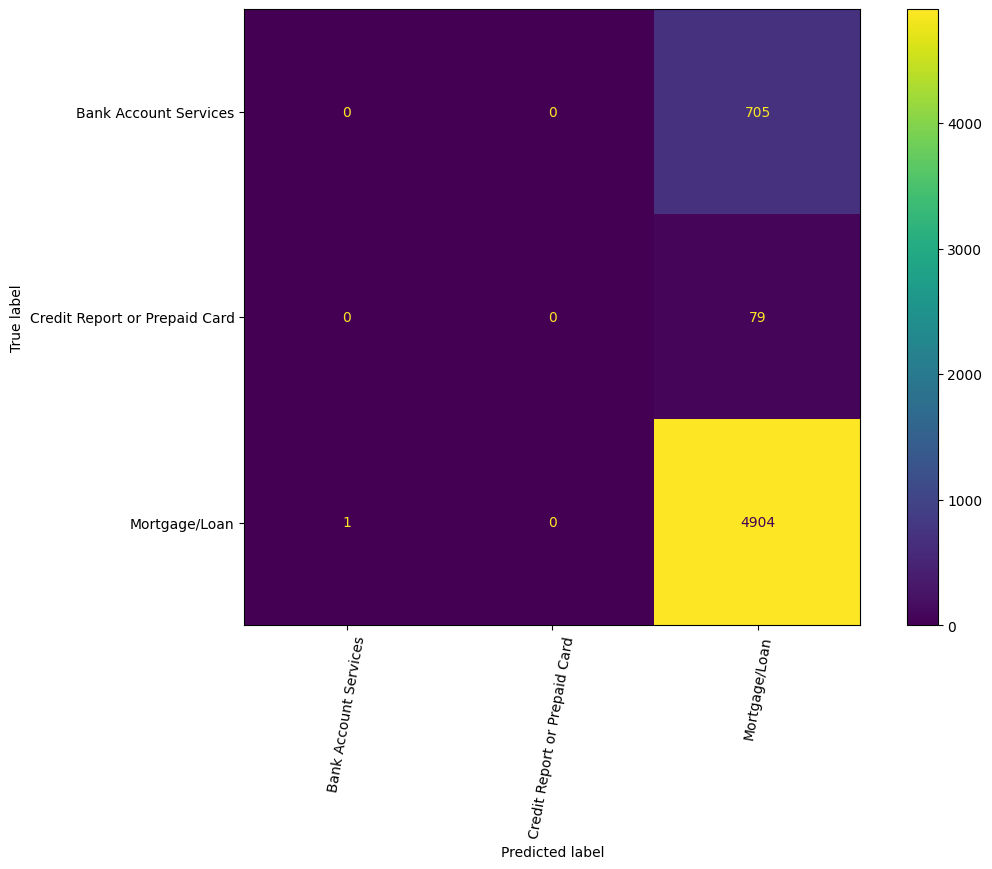

2026/06/20 13:41:06 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/20 13:41:12 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


[0.61, 0.51, 0.86, 0.86, 0.78, 0.74, 0.86, 0.86, 0.8, 0.8]

In [9]:

mnb = MultinomialNB()
mnb.fit(X_train, y_train)
display_classification_report(model=mnb, 
                              name_model="MultinomialNB", 
                              developer="Maria", 
                              X_train=X_train, 
                              X_test=X_test, 
                              y_train=y_train, 
                              y_test=y_test)

Fitting 5 folds for each of 5 candidates, totalling 25 fits


--- Logging error ---
Traceback (most recent call last):
  File "/home/brian02oriel/snap/code/247/.local/share/uv/python/cpython-3.12.13-linux-x86_64-gnu/lib/python3.12/logging/__init__.py", line 1160, in emit
    msg = self.format(record)
          ^^^^^^^^^^^^^^^^^^^
  File "/home/brian02oriel/snap/code/247/.local/share/uv/python/cpython-3.12.13-linux-x86_64-gnu/lib/python3.12/logging/__init__.py", line 999, in format
    return fmt.format(record)
           ^^^^^^^^^^^^^^^^^^
  File "/home/brian02oriel/snap/code/247/.local/share/uv/python/cpython-3.12.13-linux-x86_64-gnu/lib/python3.12/logging/__init__.py", line 703, in format
    record.message = record.getMessage()
                     ^^^^^^^^^^^^^^^^^^^
  File "/home/brian02oriel/snap/code/247/.local/share/uv/python/cpython-3.12.13-linux-x86_64-gnu/lib/python3.12/logging/__init__.py", line 392, in getMessage
    msg = msg % self.args
          ~~~~^~~~~~~~~~~
TypeError: not all arguments converted during string formatting
Call s

Best Score:  0.8639993925950524
Best Hyperparameters:  {'alpha': 1}
------------------- NAME MODEL ------------------- |  MultinomialNBCV


2026/06/20 13:41:23 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Train Accuracy:  0.86
Test Accuracy:  0.86
Classification Report for Train:
               precision    recall  f1-score   support

           0       0.25      0.00      0.00      1653
           1       0.00      0.00      0.00       148
           2       0.86      1.00      0.93     11471

    accuracy                           0.86     13272
   macro avg       0.37      0.33      0.31     13272
weighted avg       0.78      0.86      0.80     13272

Classification Report for Test:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00       705
           1       0.00      0.00      0.00        79
           2       0.86      1.00      0.93      4905

    accuracy                           0.86      5689
   macro avg       0.29      0.33      0.31      5689
weighted avg       0.74      0.86      0.80      5689



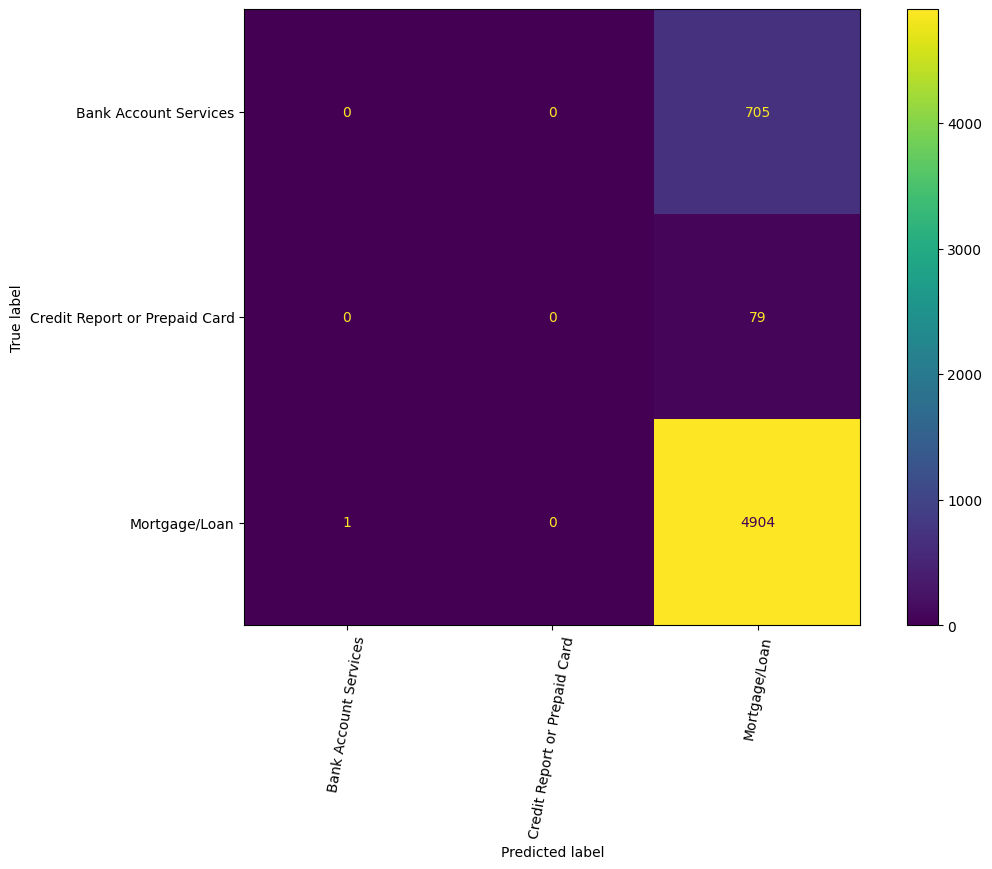

2026/06/20 13:41:23 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/20 13:41:29 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


[0.61, 0.51, 0.86, 0.86, 0.78, 0.74, 0.86, 0.86, 0.8, 0.8]

In [10]:
folds = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 40)
mnb = MultinomialNB()
mnb_params = {  
'alpha': (1, 0.1, 0.01, 0.001, 0.0001)  
}
grid_search_mnb = grid_search(mnb, folds, mnb_params, scoring="f1_micro")
grid_search_mnb.fit(X_train, y_train)
print_best_score_params(grid_search_mnb)

display_classification_report(model=grid_search_mnb, 
                              name_model="MultinomialNBCV", 
                              developer="Maria", 
                              X_train=X_train, 
                              X_test=X_test, 
                              y_train=y_train, 
                              y_test=y_test, 
                              use_cv= True)

------------------- NAME MODEL ------------------- |  LogisticRegression


--- Logging error ---
Traceback (most recent call last):
  File "/home/brian02oriel/snap/code/247/.local/share/uv/python/cpython-3.12.13-linux-x86_64-gnu/lib/python3.12/logging/__init__.py", line 1160, in emit
    msg = self.format(record)
          ^^^^^^^^^^^^^^^^^^^
  File "/home/brian02oriel/snap/code/247/.local/share/uv/python/cpython-3.12.13-linux-x86_64-gnu/lib/python3.12/logging/__init__.py", line 999, in format
    return fmt.format(record)
           ^^^^^^^^^^^^^^^^^^
  File "/home/brian02oriel/snap/code/247/.local/share/uv/python/cpython-3.12.13-linux-x86_64-gnu/lib/python3.12/logging/__init__.py", line 703, in format
    record.message = record.getMessage()
                     ^^^^^^^^^^^^^^^^^^^
  File "/home/brian02oriel/snap/code/247/.local/share/uv/python/cpython-3.12.13-linux-x86_64-gnu/lib/python3.12/logging/__init__.py", line 392, in getMessage
    msg = msg % self.args
          ~~~~^~~~~~~~~~~
TypeError: not all arguments converted during string formatting
Call s

Train Accuracy:  0.87
Test Accuracy:  0.86
Classification Report for Train:
               precision    recall  f1-score   support

           0       0.76      0.07      0.13      1653
           1       0.00      0.00      0.00       148
           2       0.87      1.00      0.93     11471

    accuracy                           0.87     13272
   macro avg       0.54      0.36      0.35     13272
weighted avg       0.85      0.87      0.82     13272

Classification Report for Test:
               precision    recall  f1-score   support

           0       0.53      0.04      0.07       705
           1       0.00      0.00      0.00        79
           2       0.87      1.00      0.93      4905

    accuracy                           0.86      5689
   macro avg       0.46      0.34      0.33      5689
weighted avg       0.81      0.86      0.81      5689



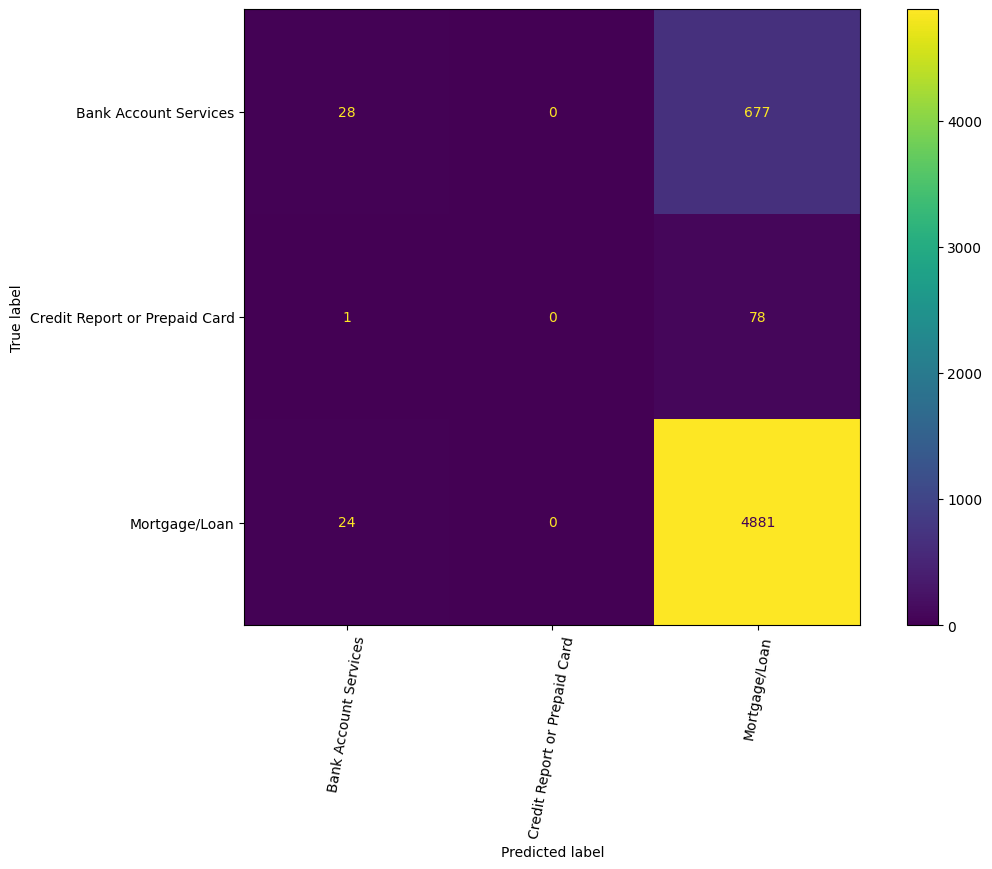

2026/06/20 13:41:41 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/20 13:41:47 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


[0.86, 0.63, 0.87, 0.86, 0.85, 0.81, 0.87, 0.86, 0.82, 0.81]

In [11]:
log_reg = LogisticRegression(random_state=40)
log_reg.fit(X_train,y_train)
display_classification_report(model=log_reg, 
                              name_model="LogisticRegression", 
                              developer="Maria", 
                              X_train=X_train, 
                              X_test=X_test, 
                              y_train=y_train, 
                              y_test=y_test, 
                              use_cv=False)

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best Score:  0.9082904812926886
Best Hyperparameters:  {'C': 10, 'penalty': 'l1', 'solver': 'saga'}
------------------- NAME MODEL ------------------- |  LogisticRegressionCVSmote


--- Logging error ---
Traceback (most recent call last):
  File "/home/brian02oriel/snap/code/247/.local/share/uv/python/cpython-3.12.13-linux-x86_64-gnu/lib/python3.12/logging/__init__.py", line 1160, in emit
    msg = self.format(record)
          ^^^^^^^^^^^^^^^^^^^
  File "/home/brian02oriel/snap/code/247/.local/share/uv/python/cpython-3.12.13-linux-x86_64-gnu/lib/python3.12/logging/__init__.py", line 999, in format
    return fmt.format(record)
           ^^^^^^^^^^^^^^^^^^
  File "/home/brian02oriel/snap/code/247/.local/share/uv/python/cpython-3.12.13-linux-x86_64-gnu/lib/python3.12/logging/__init__.py", line 703, in format
    record.message = record.getMessage()
                     ^^^^^^^^^^^^^^^^^^^
  File "/home/brian02oriel/snap/code/247/.local/share/uv/python/cpython-3.12.13-linux-x86_64-gnu/lib/python3.12/logging/__init__.py", line 392, in getMessage
    msg = msg % self.args
          ~~~~^~~~~~~~~~~
TypeError: not all arguments converted during string formatting
Call s

Train Accuracy:  0.97
Test Accuracy:  0.72
Classification Report for Train:
               precision    recall  f1-score   support

           0       0.93      0.97      0.95     11471
           1       1.00      1.00      1.00     11471
           2       0.97      0.93      0.95     11471

    accuracy                           0.97     34413
   macro avg       0.97      0.97      0.97     34413
weighted avg       0.97      0.97      0.97     34413

Classification Report for Test:
               precision    recall  f1-score   support

           0       0.18      0.29      0.22       705
           1       0.06      0.08      0.07        79
           2       0.88      0.79      0.83      4905

    accuracy                           0.72      5689
   macro avg       0.37      0.39      0.37      5689
weighted avg       0.78      0.72      0.75      5689



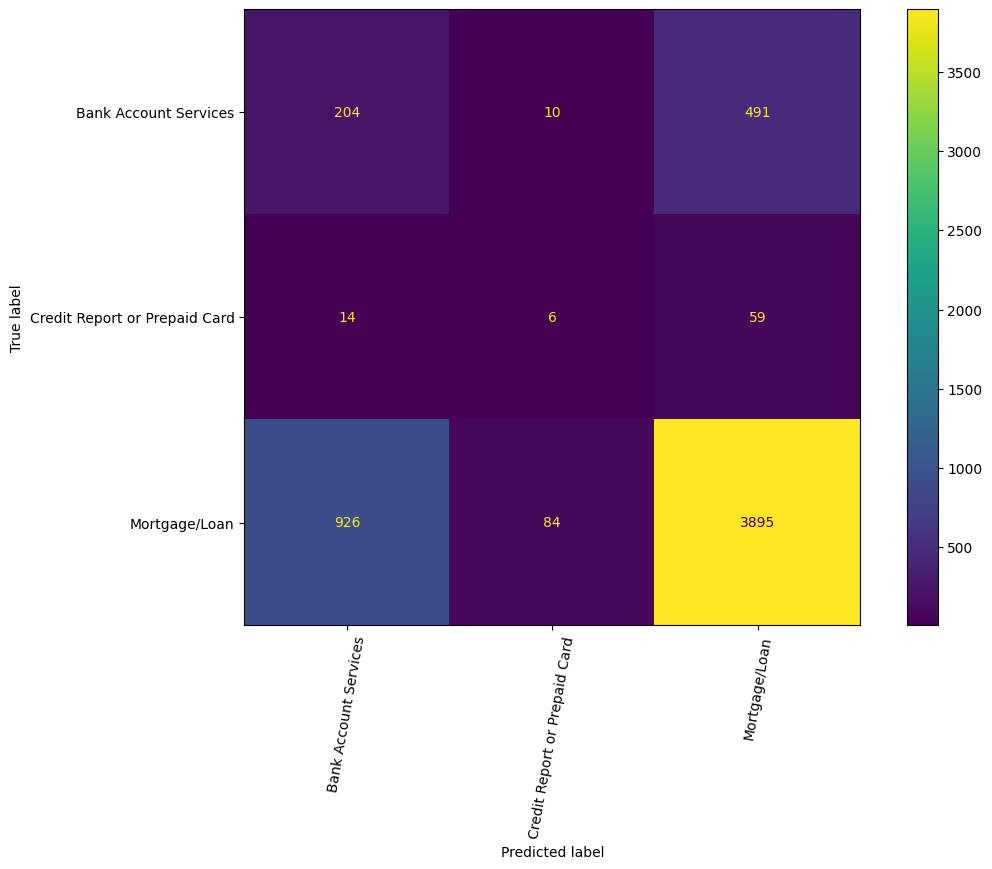

2026/06/20 13:47:05 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/20 13:47:11 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


[0.99, 0.58, 0.97, 0.72, 0.97, 0.78, 0.97, 0.72, 0.97, 0.75]

In [12]:
# rebalance of the data
smote = SMOTE()
# transform the dataset with the SMOTE algorithm
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
# define the model with the balanced class_weight
log_reg = LogisticRegression(class_weight='balanced')

log_params = {'C': [0.01, 1, 10], 
          'penalty': ['l1', 'l2'],
          'solver': ['liblinear','newton-cg','saga']
         }

grid_search_log = grid_search(log_reg, folds, log_params, scoring="f1_micro")
grid_search_log.fit(X_train_res, y_train_res)  # entrenamiento con los datos rebalanceados

print_best_score_params(grid_search_log)
display_classification_report(grid_search_log,
                              name_model="LogisticRegressionCVSmote", 
                              developer="Maria", 
                              X_train=X_train_res,  # evaluación con los datos rebalanceados
                              X_test=X_test, 
                              y_train=y_train_res,  # etiquetas rebalanceadas
                              y_test=y_test, 
                              use_cv=True)

Fitting 5 folds for each of 512 candidates, totalling 2560 fits


Best Score:  0.3820458771923012
Best Hyperparameters:  {'criterion': 'entropy', 'max_depth': None, 'max_features': None, 'min_samples_leaf': 2, 'splitter': 'best'}
------------------- NAME MODEL ------------------- |  DecisionTreeClassifierCV


--- Logging error ---
Traceback (most recent call last):
  File "/home/brian02oriel/snap/code/247/.local/share/uv/python/cpython-3.12.13-linux-x86_64-gnu/lib/python3.12/logging/__init__.py", line 1160, in emit
    msg = self.format(record)
          ^^^^^^^^^^^^^^^^^^^
  File "/home/brian02oriel/snap/code/247/.local/share/uv/python/cpython-3.12.13-linux-x86_64-gnu/lib/python3.12/logging/__init__.py", line 999, in format
    return fmt.format(record)
           ^^^^^^^^^^^^^^^^^^
  File "/home/brian02oriel/snap/code/247/.local/share/uv/python/cpython-3.12.13-linux-x86_64-gnu/lib/python3.12/logging/__init__.py", line 703, in format
    record.message = record.getMessage()
                     ^^^^^^^^^^^^^^^^^^^
  File "/home/brian02oriel/snap/code/247/.local/share/uv/python/cpython-3.12.13-linux-x86_64-gnu/lib/python3.12/logging/__init__.py", line 392, in getMessage
    msg = msg % self.args
          ~~~~^~~~~~~~~~~
TypeError: not all arguments converted during string formatting
Call s

Train Accuracy:  0.98
Test Accuracy:  0.78
Classification Report for Train:
               precision    recall  f1-score   support

           0       0.87      0.99      0.93      1653
           1       0.79      0.77      0.78       148
           2       1.00      0.98      0.99     11471

    accuracy                           0.98     13272
   macro avg       0.89      0.91      0.90     13272
weighted avg       0.98      0.98      0.98     13272

Classification Report for Test:
               precision    recall  f1-score   support

           0       0.22      0.23      0.22       705
           1       0.02      0.01      0.02        79
           2       0.88      0.87      0.87      4905

    accuracy                           0.78      5689
   macro avg       0.37      0.37      0.37      5689
weighted avg       0.78      0.78      0.78      5689



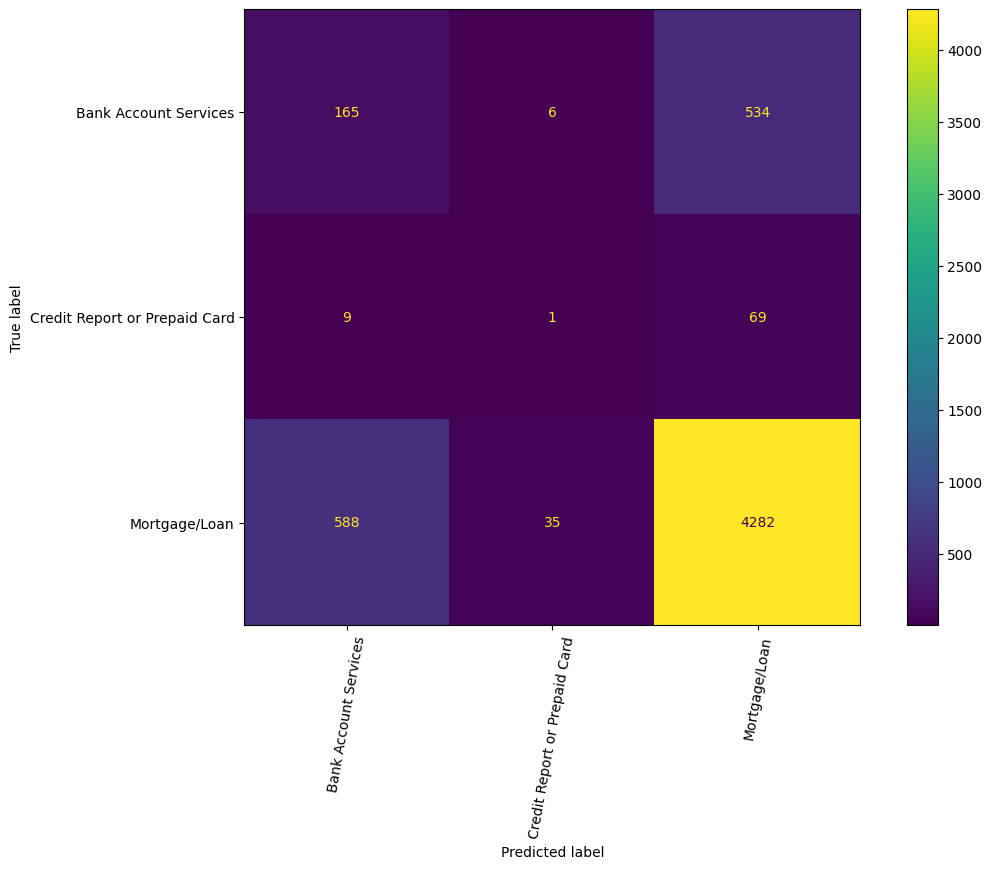

2026/06/20 13:48:58 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/20 13:49:04 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


[1.0, 0.56, 0.98, 0.78, 0.98, 0.78, 0.98, 0.78, 0.98, 0.78]

In [13]:
dtc_cv = DecisionTreeClassifier(random_state=40)

dtc_params = {
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random'],
    'max_depth': [2,3,4,5,6,7,8,None],
    'min_samples_leaf': [2,3,4,7],
    'max_features': ['auto', 'sqrt', 'log2', None]
}
grid_search_dtc = grid_search(dtc_cv, folds, dtc_params, scoring='f1_macro')
grid_search_dtc.fit(X_train, y_train)
print_best_score_params(grid_search_dtc)
display_classification_report(grid_search_dtc, 
                              name_model="DecisionTreeClassifierCV", 
                              developer="Maria", 
                              X_train=X_train, 
                              X_test=X_test, 
                              y_train=y_train, 
                              y_test=y_test, 
                              use_cv=True)